# Single-cell Hi-C — imputation and cell-cycle embedding

Single-cell Hi-C resolves 3D genome folding **per cell**, but each cell's contact matrix is
extremely sparse. `ov.epi.single.hic` wraps epione's scHi-C tools (a scHiCluster-style random-walk
imputation + a cell embedding) so you can go from a raw `.scool` to a cell map.

**Data.** Nagano et al. 2017 mouse embryonic-stem-cell scHi-C (GEO **GSE94489**) as a 1 Mb
`.scool` plus the published per-cell feature/README tables (which carry each cell's **cell-cycle
phase** and replication score). Point `DATA` at your copy; the executed outputs use a local cache.

1. join the metadata and select a phase-stratified subset (`ov.epi.single.hic.load_scool_cells`)
2. show one raw cell matrix (sparse) vs. its imputed version
3. embed all cells (`ov.epi.single.hic.embedding`) and colour by cell-cycle phase

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pathlib
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import omicverse as ov
ov.epi.pl.plot_set()
print('omicverse', ov.__version__)

shic = ov.epi.single.hic
DATA = pathlib.Path('/scratch/users/steorra/data/sc-hic-nagano')
SCOOL = DATA / 'nagano_1MB_raw.scool'

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.

omicverse 2.2.1rc1


## 1 · Build the cell table and select cells

The feature table gives each cell a cell-cycle `group`, a `repli_score` and a `total_contacts`;
the README maps each cell to its barcodes, from which we reconstruct the `.scool` cell key. We keep
well-covered cells in three phases and sample an equal number from each.

In [2]:
feat = pd.read_csv(DATA / 'GSE94489_2i_diploids_features_table.txt.gz', sep='\t')
feat = feat[feat['passed_qc'] == 1].copy()
readme = pd.read_csv(DATA / 'GSE94489_README.txt', sep='\t', dtype=str)
# README 'Name' uses dashes (1CDU-1); the feature table 'cell_nm' uses underscores.
readme['cell_nm_us'] = readme['Name'].str.replace('-', '_', regex=False)

cells = feat.merge(
    readme[['Nature_Reference_ID', 'Five_prime_barcode', 'Three_prime_barcode', 'cell_nm_us']],
    left_on='cell_nm', right_on='cell_nm_us', how='inner')
cells['scool_name'] = (cells['Nature_Reference_ID'] + '_' + cells['Five_prime_barcode']
                       + '_' + cells['Three_prime_barcode'] + '_R1fastqgz')

with h5py.File(SCOOL) as h:
    scool_keys = {k for k in h.keys() if isinstance(h[k], h5py.Group)}
cells = cells[cells['scool_name'].isin(scool_keys) & (cells['total_contacts'] > 5000)]

KEEP = ['G1', 'early-S', 'late-S/G2']
strat = (cells[cells['group'].isin(KEEP)]
         .groupby('group', group_keys=False)
         .apply(lambda g: g.sample(min(30, len(g)), random_state=0))
         .reset_index(drop=True))
print(strat['group'].value_counts().to_string())

group
G1           30
early-S      30
late-S/G2    30


In [3]:
CHROMS = [f'chr{i}' for i in range(1, 20)] + ['chrX']
obs = strat.set_index('scool_name')[['group', 'repli_score', 'total_contacts']]
adata = shic.load_scool_cells(
    str(SCOOL), cell_names=strat['scool_name'].tolist(), obs=obs, chromosomes=CHROMS)
print(adata)

AnnData object with n_obs × n_vars = 90 × 0
    obs: 'cool_path', 'group', 'repli_score', 'total_contacts'
    uns: 'hic'


## 2 · Raw vs. imputed single-cell contact map

A single raw 1 Mb cell matrix is mostly empty. scHiCluster-style imputation
(`ov.epi.single.hic.impute_cells`, a random walk with restart on each cell's contact graph) fills
in the structure so cells become comparable. We show the same cell + chromosome before and after.

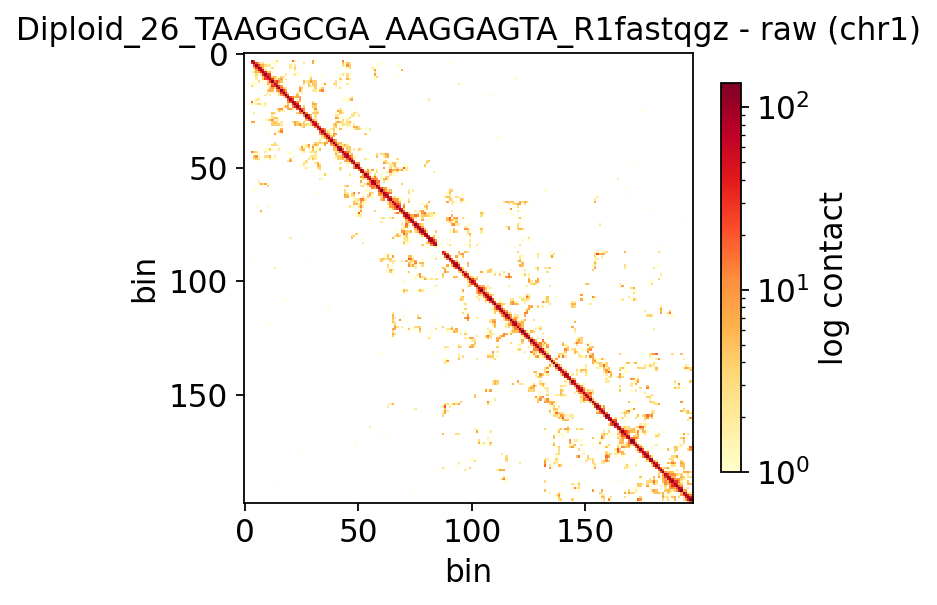

In [4]:
demo = adata.obs['total_contacts'].astype(float).idxmax()
fig, ax = shic.plot_cell_contacts(adata, cell_id=demo, chromosome='chr1',
                                  use_imputed=False, log=True, figsize=(4.5, 4))
ax.set_title(f'{demo} - raw (chr1)')
plt.show()

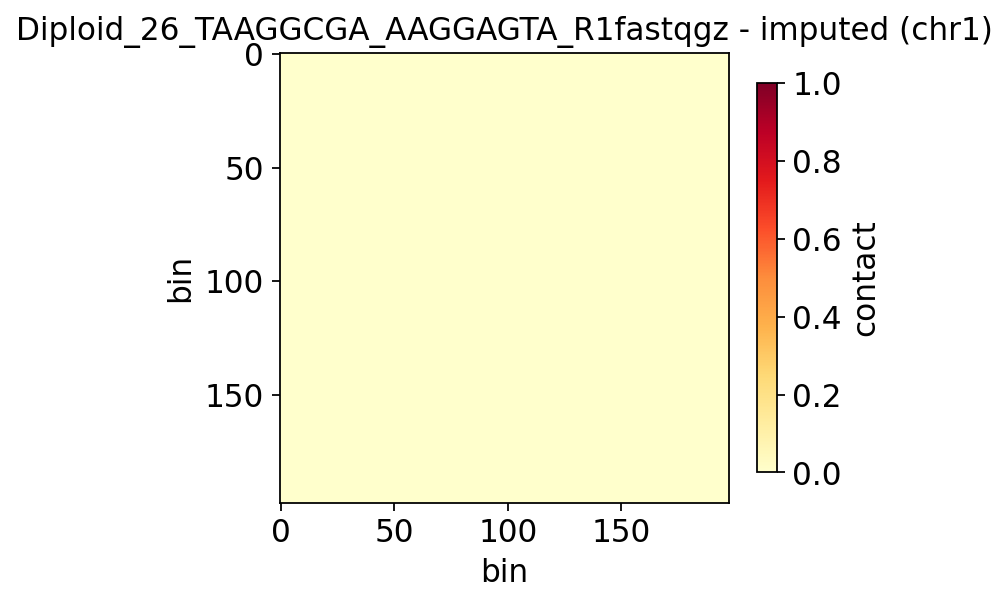

In [5]:
IMPUTED = os.path.join(os.getcwd(), 'data_epi', 'schic_imputed')
os.makedirs(IMPUTED, exist_ok=True)
shic.impute_cells(adata, out_dir=IMPUTED, pad=1, rwr_alpha=0.05, top_pct=0.05, progress=False)

fig, ax = shic.plot_cell_contacts(adata, cell_id=demo, chromosome='chr1',
                                  use_imputed=True, log=False, figsize=(4.5, 4))
ax.set_title(f'{demo} - imputed (chr1)')
plt.show()

## 3 · Cell embedding coloured by cell-cycle phase

`ov.epi.single.hic.embedding` flattens each imputed cell into a feature vector and runs PCA.
Adding a UMAP on top, the cells order by **cell-cycle phase** — the dominant axis of variation in
mES scHi-C — recapitulating the Nagano 2017 result.

embedding: (90, 8128)


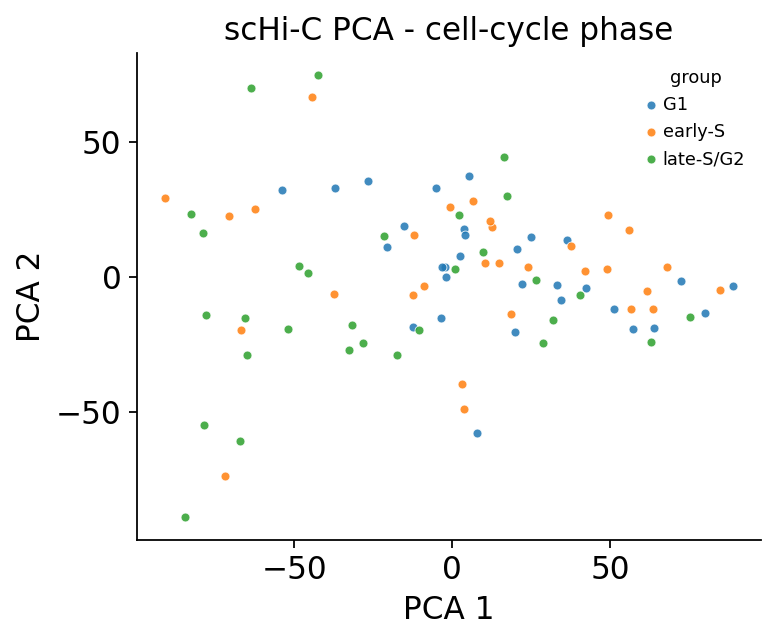

In [6]:
embed = shic.embedding(adata, n_components=20, standardise=True)
print('embedding:', embed.shape)

fig, ax = shic.plot_embedding(embed, basis='X_pca', components=(1, 2), color='group',
                              cmap='tab10', figsize=(5, 4))
ax.set_title('scHi-C PCA - cell-cycle phase')
plt.show()

computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:10)


computing UMAP


    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)


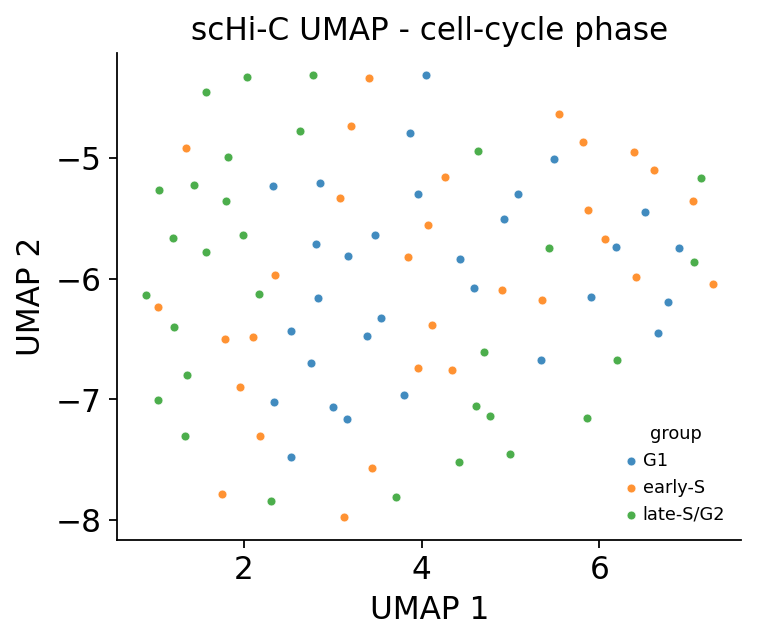

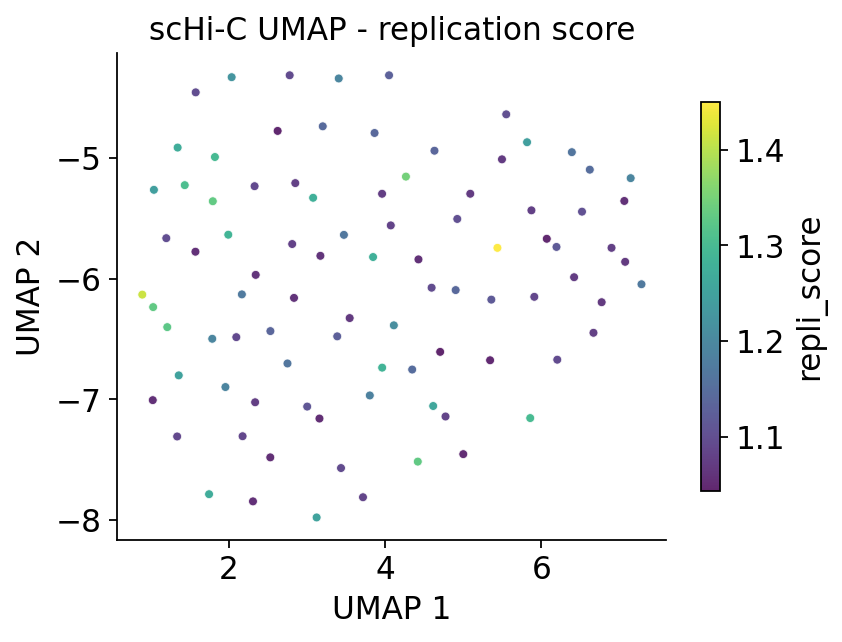

In [7]:
import scanpy as sc
sc.pp.neighbors(embed, n_neighbors=15, use_rep='X_pca')
sc.tl.umap(embed, min_dist=0.4, random_state=0)

fig, ax = shic.plot_embedding(embed, basis='X_umap', components=(1, 2), color='group',
                              cmap='tab10', figsize=(5, 4))
ax.set_title('scHi-C UMAP - cell-cycle phase')
plt.show()

fig, ax = shic.plot_embedding(embed, basis='X_umap', components=(1, 2), color='repli_score',
                              figsize=(5.5, 4))
ax.set_title('scHi-C UMAP - replication score')
plt.show()

## Summary

| stage | function |
|---|---|
| load cells from `.scool` | `ov.epi.single.hic.load_scool_cells` |
| raw / imputed cell matrix | `ov.epi.single.hic.plot_cell_contacts` |
| imputation | `ov.epi.single.hic.impute_cells` |
| cell embedding | `ov.epi.single.hic.embedding` + `plot_embedding` |

Imputation turns sparse per-cell contact maps into comparable feature vectors, and the resulting
embedding recovers cell-cycle structure — the scHi-C analogue of a scRNA/scATAC cell map.